In [30]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [4]:
DISCHARGE_PATH = Path("/data0/nksp2/skagit/skagit_2/skagit-met/experiments_2/data/usgs_12200500_discharge.rdb")

In [5]:
def load_usgs_rdb(filepath, param_name):
    """Load USGS RDB files."""
    print(f"Loading {param_name} from {filepath}...")
    try:
        df = pd.read_csv(filepath, sep='\t', comment='#')
        df = df.iloc[1:].reset_index(drop=True)
        val_cols = [c for c in df.columns if '_00' in c and not c.endswith('_cd')]
        if not val_cols: return pd.DataFrame(columns=['date', param_name])
        val_col = val_cols[0]
        df = df[['datetime', val_col]]
        df.columns = ['date', param_name]
        df['date'] = pd.to_datetime(df['date'])
        df[param_name] = pd.to_numeric(df[param_name], errors='coerce')
        return df
    except Exception as e:
        print(f"  Error loading {filepath}: {e}")
        return pd.DataFrame(columns=['date', param_name])

In [15]:
drainage_area_mi2 = 3093 #mi^2
drainage_area_ft2 = drainage_area_mi2 * 27878400 #ft^2

In [55]:
df_discharge_all = load_usgs_rdb(DISCHARGE_PATH, 'discharge_cfs')
df_discharge_all['date'] = pd.to_datetime(df_discharge_all['date'])
df_discharge_all = df_discharge_all[
    (df_discharge_all['date'] > pd.to_datetime('1990-11-21')) &
    (df_discharge_all['date'] < pd.to_datetime('1990-11-29'))
]

df_discharge_all['discharge_fts'] = df_discharge_all['discharge_cfs'] / drainage_area_ft2
df_discharge_all['discharge_ftd'] = df_discharge_all['discharge_fts'] * 60 * 60 * 24
df_discharge_all['discharge_mmd'] = df_discharge_all['discharge_ftd'] * 304.8
df_discharge_all

Loading discharge_cfs from /data0/nksp2/skagit/skagit_2/skagit-met/experiments_2/data/usgs_12200500_discharge.rdb...


,date,discharge_cfs,discharge_fts,discharge_ftd,discharge_mmd
3978,1990-11-22,42600,4.940397e-07,0.042685,13.010397
3979,1990-11-23,64100,7.433790e-07,0.064228,19.576677
3980,1990-11-24,97200,1.127245e-06,0.097394,29.685694
3981,1990-11-25,142000,1.646799e-06,0.142283,43.367989
3982,1990-11-26,81200,9.416907e-07,0.081362,24.799160
3983,1990-11-27,50900,5.902962e-07,0.051002,15.545286
3984,1990-11-28,51100,5.926157e-07,0.051202,15.606368


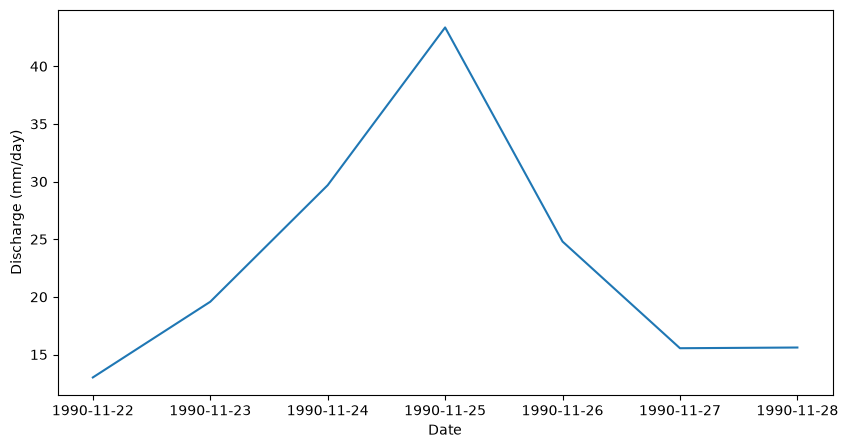

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(df_discharge_all['date'], df_discharge_all['discharge_mmd']) 
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.show()


In [57]:
df_discharge_all['cum_area_mmd'] = cumulative_trapezoid(
    df_discharge_all['discharge_mmd'],
    x=df_discharge_all['date'].astype('int64') / 8.64e13,  # convert ns -> days
    initial=0
)

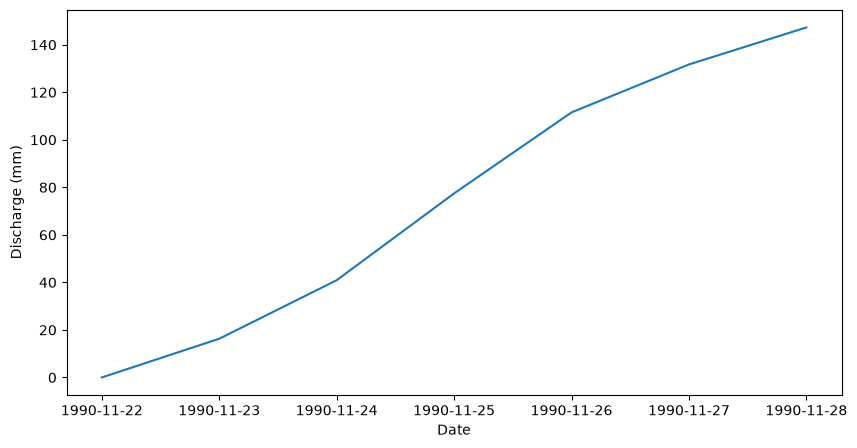

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(df_discharge_all['date'], df_discharge_all['cum_area_mmd']) 
plt.xlabel('Date')
plt.ylabel('Discharge (mm)')
plt.show()